<a href="https://colab.research.google.com/github/lorenzobalzani/nlp_projects/blob/master/project/nlp_project_emotion_trigger_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Head Neural Network for Emotion Classification and Trigger Extraction in Multi-Utterance Dialogues
## Project Report for the Natural Language Processing Course

### Authors: Lorenzo Balzani, Alessia Deana, and Thomas Guizzetti

To obtain the weights of all models and the dataset, kindly consult [this](https://huggingface.co/balzanilo) HuggingFace hub profile for downloading.



# Setup

In [114]:
%%capture
%pip install evaluate transformers[torch] huggingface_hub gdown
!sudo apt-get install git-lfs # for hugging-face hub

import gdown
import json
import pandas as pd
from typing import List, Dict, Tuple
from tqdm import tqdm

from transformers import BertModel, BertTokenizer, AutoModel
from huggingface_hub import PyTorchModelHubMixin
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, AutoTokenizer, EarlyStoppingCallback, pipeline, get_linear_schedule_with_warmup
from datasets import Dataset, DatasetDict, load_dataset
import evaluate
import statistics

from collections import Counter
from itertools import chain

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def display_markdown(markdown_text: str):
    display(Markdown(markdown_text))

seeds: List[int] = [42, 64, 512, 1024, 4096]
general_random_state: int = seeds[0]

## Hugging-Face (Optional)

In [81]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To login, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Token: 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
Your token has been saved to /root/.c

# Dataset

## Download, Pre-Processing, and Uploading

In [3]:
training_set_filename = f"MELD_train_efr.json"

try:
  print(f"Attempting to download {training_set_filename} from Drive...")
  file_id = "1wVNU2XvvhqjaGXZM-JLJwOt97gt4g9j2"  # Extracted File ID from your provided URL
  url = f"https://drive.google.com/uc?id={file_id}"
  gdown.download(url, training_set_filename, quiet=False)
  with open(training_set_filename, "r") as file:
        training_set_json = json.load(file)

  print(f"\nSuccessfully downloaded {training_set_filename} from Drive!")
except:
  print(f"Error loading {training_set_filename} set from Drive")

Attempting to download MELD_train_efr.json from Drive...


Downloading...
From: https://drive.google.com/uc?id=1wVNU2XvvhqjaGXZM-JLJwOt97gt4g9j2
To: /content/MELD_train_efr.json
100%|██████████| 5.18M/5.18M [00:00<00:00, 35.4MB/s]



Successfully downloaded MELD_train_efr.json from Drive!


In [4]:
df = pd.DataFrame(training_set_json)

# Check the number of NaN values within the lists in the 'triggers' column
nan_count_before = df["utterances"].apply(lambda x: pd.Series(x).isna().sum()).sum()

# Display the number of NaN values
print(f"Number of NaN values in the 'triggers' column lists: {nan_count_before}")

# Replace NaN values within each list in the 'triggers' column with 0.0
df["triggers"] = df["triggers"].apply(lambda x: [0.0 if pd.isna(val) else val for val in x])

# Check again the number of NaN values within the lists in the 'triggers' column
nan_count_after = df["triggers"].apply(lambda x: pd.Series(x).isna().sum()).sum()

# Display the number of NaN values after replacing with 0s
print(f"Number of NaN values in the 'triggers' column lists after replacing: {nan_count_after}")

Number of NaN values in the 'triggers' column lists: 0
Number of NaN values in the 'triggers' column lists after replacing: 0


In [5]:
train_ratio: float = 0.8
val_ratio: float = 0.1
test_ratio: float = 0.1
columns_to_keep: List[str] = ["utterances", "emotions", "triggers"]

labels_emotions = [label for label in df.explode("emotions")["emotions"].unique()]
num_emotions: int = len(labels_emotions)
id2label_emotions = {idx:label for idx, label in enumerate(labels_emotions)}
label2id_emotions = {label:idx for idx, label in enumerate(labels_emotions)}

df["emotions"] = df["emotions"].apply(lambda emotions: [label2id_emotions[emotion] for emotion in emotions])

train_data, temp_data = train_test_split(df, test_size=(1-train_ratio), random_state=general_random_state)
eval_data, test_data = train_test_split(temp_data, test_size=(test_ratio / (val_ratio + test_ratio)),
                                        random_state=general_random_state)
train_data = train_data[columns_to_keep].reset_index(drop=True)
eval_data = eval_data[columns_to_keep].reset_index(drop=True)
test_data = test_data[columns_to_keep].reset_index(drop=True)

dataset_url_hf_hub: str = "balzanilo/dialogs-mtl-dataset"

try:
  dataset_hf = DatasetDict({
      "train":  Dataset.from_pandas(train_data),
      "test": Dataset.from_pandas(test_data),
      "eval": Dataset.from_pandas(eval_data),
  })
  dataset_hf.push_to_hub(dataset_url_hf_hub, private=False)
except Exception:
  print(f"Error: Uploading the dataset requires being logged in as '{dataset_url_hf_hub.split('/')[0]}' on the HuggingFace Hub.")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/638 [00:00<?, ?B/s]

## PyTorch Dataset Adaptation

In [ ]:
class EmotionTriggerDataset(Dataset):
    def __init__(self, dataset, encoder_model_name: str, max_tokens_per_sentence: int, pad_targets: bool = False):
        self.dataset = dataset
        self.tokenizer =  AutoTokenizer.from_pretrained(encoder_model_name)
        self.max_tokens_per_sentence = max_tokens_per_sentence
        self.__pad_targets = pad_targets

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        if type(idx) == list:
          idx = idx[0] # ONLY works with batch_size = 1
        tokenized_dialogue = self.tokenizer(self.dataset.iloc[idx]["utterances"], truncation=True, padding="max_length", max_length=self.max_tokens_per_sentence, return_tensors='pt')

        emotions = self.dataset.iloc[idx]["emotions"]
        triggers = self.dataset.iloc[idx]["triggers"]

        if self.__pad_targets:
          emotion_labels = torch.nn.functional.pad(torch.tensor(emotions), (0, self.max_tokens_per_sentence - len(emotions)), value=-1)
          trigger_labels = torch.nn.functional.pad(torch.tensor(triggers), (0, self.max_tokens_per_sentence - len(triggers)), value=-1)
        else:
          emotion_labels = emotions
          trigger_labels = triggers

        return {"input_ids": tokenized_dialogue["input_ids"],
                "attention_mask": tokenized_dialogue["attention_mask"],
                "emotions": torch.LongTensor(emotion_labels),
                "triggers": torch.FloatTensor(trigger_labels)}

bert_model_name = "bert-base-uncased"
roberta_large_model_name = "roberta-large"
max_tokens_per_sentence: int = 25

# Create PyTorch Dataset(s)
bert_train_dataset = EmotionTriggerDataset(train_data, bert_model_name, max_tokens_per_sentence)
bert_eval_dataset = EmotionTriggerDataset(eval_data, bert_model_name, max_tokens_per_sentence)
bert_test_dataset = EmotionTriggerDataset(test_data, bert_model_name, max_tokens_per_sentence)

roberta_large_train_dataset = EmotionTriggerDataset(train_data, roberta_large_model_name, max_tokens_per_sentence)
roberta_large_eval_dataset = EmotionTriggerDataset(eval_data, roberta_large_model_name, max_tokens_per_sentence)
roberta_large_test_dataset = EmotionTriggerDataset(test_data, roberta_large_model_name, max_tokens_per_sentence)

# Initialize PyTorch DataLoader(s)
bert_train_dataloader = DataLoader(bert_train_dataset, batch_size=1, shuffle=True)
bert_eval_dataloader = DataLoader(bert_eval_dataset, batch_size=1, shuffle=False)
bert_test_dataloader = DataLoader(bert_test_dataset, batch_size=1, shuffle=False)

roberta_large_train_dataloader = DataLoader(roberta_large_train_dataset, batch_size=1, shuffle=True)
roberta_large_eval_dataloader = DataLoader(roberta_large_eval_dataset, batch_size=1, shuffle=False)
roberta_large_test_dataloader = DataLoader(roberta_large_test_dataset, batch_size=1, shuffle=False)

In [7]:
for batch_data in bert_train_dataloader:
    # Extract information about the batch
    n_sentences = batch_data["input_ids"].shape[0]
    n_tokens = batch_data["input_ids"].shape[-1]
    n_emotions = batch_data["emotions"].shape[0]
    n_triggers = batch_data["triggers"].shape[0]

    # Display batch information
    print(f"Batch Information - Batch Size: 1, Sentences: {n_sentences}, Tokens per Sentence: {n_tokens}, Emotions: {n_emotions}, Triggers: {n_triggers}")
    break

Batch Information - Batch Size: 1, Sentences: 6, Tokens per Sentence: 25, Emotions: 6, Triggers: 6


# Baselines

In [8]:
dialogue = ["I feel happy.", "This is a sad moment Hugo, please.", "I am excited!", "Best, Laura!"]

## Random Classifier

In [9]:
class RandomClassifier:
    def __init__(self, num_emotions: int, seed: int) -> None:
        self.__num_emotions = num_emotions
        np.random.seed(seed)

    def __call__(self, dialogue: List[str]) -> Tuple[List[int], List[int]]:
        emotions = np.random.rand(len(dialogue), self.__num_emotions)
        emotions = emotions / emotions.sum(axis=1, keepdims=True)
        triggers = np.random.randint(2, size=len(dialogue))
        return np.argmax(emotions, axis=1), triggers

random_classifier = RandomClassifier(num_emotions, seed=general_random_state)
emotions, trigger_probs = random_classifier(dialogue)
print("Emotions:", emotions)
print("Triggers:", trigger_probs)

Emotions: [1 4 6 4]
Triggers: [1 0 0 0]


## Majority Classifier

In [10]:
class MajorityClassifier:
    def __init__(self, data: pd.DataFrame) -> None:
        self.__majority_emotion = self.__calculate_majority_label(data, key="emotions")
        self.__majority_trigger = self.__calculate_majority_label(data, key="triggers")

    def __calculate_majority_label(self, data: pd.DataFrame, key: str) -> int:
        all_lists = [d[1][key] for d in train_data.iterrows()]
        final_list = list(chain(*all_lists))
        most_frequent_item = Counter(final_list).most_common(1)[0][0]
        return int(most_frequent_item)

    def __call__(self, dialogue: List[str]) -> Tuple[List[int], List[int]]:
        emotions = np.tile(self.__majority_emotion, len(dialogue))
        triggers = np.tile(self.__majority_trigger, len(dialogue))
        return emotions, triggers

majority_classifier = MajorityClassifier(train_data)
emotions, trigger_probs = majority_classifier(dialogue)
print("Emotions:", emotions)
print("Triggers:", trigger_probs)

Emotions: [0 0 0 0]
Triggers: [0 0 0 0]


# Our solution: Model Definition

This PyTorch model is designed for emotion and trigger prediction in text data. Here's a breakdown of its components:

1. **Initialization:**
   - `EmotionTriggerModel` is a class that inherits from `nn.Module`.
   - It takes several parameters during initialization:
      - `model_name`: A string specifying the name of a pre-trained transformer model (assumed to be a BERT-based model).
      - `num_emotions`: An integer indicating the number of emotion classes for prediction.
      - `num_lstm_layers`: An integer indicating the number of LSTM hidden layers.
      - `lstm_hidden_size`: An integer specifying the hidden size of the LSTM layer(s) for trigger prediction.
      - `ffnn_hidden_size`: An integer specifying the hidden size of the feed-forward neural networks.
      - `random_state`: An integer representing the random seed for reproducibility.

2. **BERT Model and Tokenizer:**
   - It uses a BERT-based model for sequence classification (`AutoModelForSequenceClassification`) with a specified number of output labels (`num_emotions`).
   - The BERT model is expected to return hidden states (`output_hidden_states=True`).

3. **Emotion Feed-forward Neural Network:**
   - A feed-forward neural network for emotion prediction is defined using `nn.Sequential`.
   - It consists of a linear layer, ReLU activation, another linear layer, and a softmax activation function for multi-class emotion prediction.

4. **LSTM for Trigger Prediction:**
   - An LSTM layer is defined for trigger prediction.
   - The input size to the LSTM includes the BERT hidden size and an additional dimension for the predicted emotion.
   - It is a bidirectional LSTM (`bidirectional=True`).

5. **Feed-forward Neural Network for Trigger Prediction:**
   - Another feed-forward neural network is defined for trigger prediction after the LSTM layer.
   - It consists of a linear layer, ReLU activation, another linear layer, and a sigmoid activation function for binary trigger prediction.

6. **Forward Method:**
   - The `forward` method takes input IDs, attention mask, and token type IDs as input parameters.
   - It passes the input through the BERT model to obtain hidden states.
   - The CLS token is extracted from the last hidden states for emotion prediction.
   - Emotion prediction is performed using the feed-forward neural network.
   - The final trigger prediction is obtained using the feed-forward neural network for triggers.
   - The method returns tensors representing predicted emotions and trigger probabilities.

In summary, this model is a combination of a BERT-based emotion classifier and an LSTM-based trigger predictor for text data. It is designed to jointly predict emotions and triggers in a given sequence of text.

In [110]:
class EmotionTriggerModel(nn.Module, PyTorchModelHubMixin):
    def __init__(self, encoder_model_name: str,
                 num_emotions: int,
                 num_lstm_layers: int,
                 lstm_hidden_size: int,
                 ffnn_hidden_size: int,
                 freeze_encoder: bool = False,
                 random_state: int = None) -> None:
        super().__init__()

        if random_state is not None:
          torch.manual_seed(random_state)
          torch.cuda.manual_seed_all(random_state)

        # Encoder model for emotion prediction
        self.encoder_model = AutoModelForSequenceClassification.from_pretrained(encoder_model_name,
                                                                                num_labels=num_emotions,
                                                                                output_hidden_states=True)
        if freeze_encoder:
            for param in self.encoder_model.parameters():
                param.requires_grad = False

        # Feed-forward neural network for emotion prediction
        self.emotion_ffnn = nn.Sequential(
            nn.Linear(self.encoder_model.config.hidden_size, ffnn_hidden_size),
            nn.ReLU(),
            nn.Linear(ffnn_hidden_size, num_emotions),
        )

        # LSTM for trigger prediction
        self.lstm = nn.LSTM(input_size=self.encoder_model.config.hidden_size,
                            hidden_size=lstm_hidden_size,
                            num_layers=num_lstm_layers,
                            batch_first=True,
                            bidirectional=True)

        # Feed-forward neural network for trigger prediction
        self.trigger_ffnn = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, ffnn_hidden_size),
            nn.ReLU(),
            nn.Linear(ffnn_hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
      # Get encoder embeddings for each sentence
      encoder_outputs = self.encoder_model(**{"input_ids": input_ids,
                                              "attention_mask": attention_mask}).hidden_states[-1]

      # Extract CLS token for emotion prediction
      cls_tokens = encoder_outputs[:, 0, :]

      # Emotion prediction
      emotions_logits = self.emotion_ffnn(cls_tokens)

      # LSTM for trigger prediction
      lstm_outputs, _ = self.lstm(cls_tokens)

      # Feed-forward neural network for trigger prediction
      trigger_probs = self.trigger_ffnn(lstm_outputs)

      return emotions_logits, trigger_probs.squeeze()

## Example usage

In [111]:
encoder_model_name = "bert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionTriggerModel(encoder_model_name,
                            num_emotions,
                            num_lstm_layers=16,
                            lstm_hidden_size=256,
                            ffnn_hidden_size=128,
                            random_state=general_random_state).to(device)
tokenizer = AutoTokenizer.from_pretrained(encoder_model_name)
dialogue = ["I feel happy.", "This is a sad moment Hugo, please.", "I am excited!", "Best, Laura!"]
emotions, trigger_probs = model(**tokenizer(dialogue, return_tensors='pt', padding=True, truncation=True).to(device))
print("Emotion logits:", emotions)
print("Trigger Probabilities:", trigger_probs)

tensor([[ 101, 1045, 2514, 3407, 1012,  102,    0,    0,    0,    0,    0],
        [ 101, 2023, 2003, 1037, 6517, 2617, 9395, 1010, 3531, 1012,  102],
        [ 101, 1045, 2572, 7568,  999,  102,    0,    0,    0,    0,    0],
        [ 101, 2190, 1010, 6874,  999,  102,    0,    0,    0,    0,    0]],
       device='cuda:0')
Emotion logits: tensor([[-0.0596,  0.1223, -0.0255, -0.0600, -0.0590, -0.0730,  0.0991],
        [ 0.0158,  0.0793, -0.1064, -0.0915, -0.0772, -0.1074,  0.1405],
        [-0.0970,  0.0400, -0.0419, -0.1005, -0.0280,  0.0099,  0.1430],
        [-0.0347,  0.0029, -0.0313, -0.1006, -0.0043, -0.0159,  0.1645]],
       device='cuda:0', grad_fn=<AddmmBackward0>)
Trigger Probabilities: tensor([0.4982, 0.4983, 0.4981, 0.4976], device='cuda:0',
       grad_fn=<SqueezeBackward0>)


# Our solution: Training

Execute training with a batch size of 1, meaning one dialogue is processed at a time. The model will be fed tokenized dialogues along with their attention masks, resulting in a PyTorch tensor with a shape of `[batch_size, n_sentences, n_tokens_per_sentence]`. This tensor is then passed through the model (after unsqueezing it to remove the first dimension). The model returns two results: emotions and triggers. Two loss functions are computed and combined weighting the values, and the parameters are updated through backward propagation.

Concerning randomness, seeding the code before iterating through the DataLoader is equivalent to seeding it before creating the DataLoader itself ([source](https://discuss.pytorch.org/t/reproducibility-dataloader-shuffle-true-using-seeds/173836)).

## Training: PyTorch Loop(s)

In [25]:
class EarlyStopper:
    def __init__(self, patience: int = 1, min_delta: int = 0) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.min_validation_loss = float("inf")
        self.__epochs_no_improve = 0

    def early_stop(self, validation_loss: float) -> Tuple[bool, bool]:
        new_best_loss: bool = validation_loss < self.min_validation_loss
        if new_best_loss:
            self.min_validation_loss = validation_loss
            self.__epochs_no_improve = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.__epochs_no_improve += 1
            if self.__epochs_no_improve >= self.patience:
                return True, new_best_loss
        return False, new_best_loss

In [26]:
@torch.inference_mode()
def evaluate_model(model: nn.Module,
                   eval_dataloader: torch.utils.data.DataLoader,
                   criterion_emotion,
                   criterion_trigger,
                   device: str) -> float:
    model.eval()
    total_loss: float = 0.0
    with torch.no_grad():
        for idx, batch in enumerate(tqdm(eval_dataloader, desc=f"Evaluating...", leave=False)):
          input_ids = batch["input_ids"].to(device)
          attention_mask = batch["attention_mask"].to(device)
          emotion_labels = batch["emotions"].to(device)
          trigger_labels = batch["triggers"].to(device)

          emotion_logits, trigger_probs = model(input_ids=input_ids, attention_mask=attention_mask)

          emotion_loss = criterion_emotion(emotion_logits, emotion_labels)
          trigger_loss = criterion_trigger(trigger_probs, trigger_labels)

          loss = 0.8 * emotion_loss + 0.2 * trigger_loss # penalize more the emotion, since it holds higher loss values
          total_loss += loss.item()

    return total_loss / len(eval_dataloader)

def train_model(model: EmotionTriggerModel,
                num_epochs: int,
                train_dataloader: torch.utils.data.DataLoader,
                eval_dataloader: torch.utils.data.DataLoader,
                optimizer,
                scheduler,
                criterion_emotion,
                criterion_trigger,
                device: str,
                model_url: str) -> Dict[str, List[float]]:
    model.to(device)
    train_losses: List[float] = list()
    eval_losses: List[float] = list()
    early_stopper = EarlyStopper(patience=1, min_delta=1e-2)

    for epoch in range(1, num_epochs+1):
      model.train()
      total_loss: float = 0.0
      for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}/{num_epochs}", leave=False):
          input_ids = batch["input_ids"].to(device)
          attention_mask = batch["attention_mask"].to(device)
          emotion_labels = batch["emotions"].to(device)
          trigger_labels = batch["triggers"].to(device)

          optimizer.zero_grad()

          emotion_logits, trigger_probs = model(input_ids=input_ids, attention_mask=attention_mask)

          emotion_loss = criterion_emotion(emotion_logits, emotion_labels)
          trigger_loss = criterion_trigger(trigger_probs, trigger_labels)

          loss = 0.8 * emotion_loss + 0.2 * trigger_loss # penalize more the emotion, since it holds higher loss values
          total_loss += loss.item()

          loss.backward()
          optimizer.step()
          scheduler.step()

      # Avg losses
      avg_train_loss: float = total_loss / len(train_dataloader)
      train_losses.append(avg_train_loss)

      avg_eval_loss: float = evaluate_model(model, eval_dataloader, criterion_emotion, criterion_trigger, device)
      eval_losses.append(avg_eval_loss)
      print(f"Epoch {epoch}/{num_epochs}, Avg Train Loss: {avg_train_loss:.4f}, Avg Validation Loss: {avg_eval_loss:.4f}")

      # Early stopping
      trigger_early_stopping, found_best_loss = early_stopper.early_stop(avg_eval_loss)
      if trigger_early_stopping:
        print("Early stopped triggered.")
        break

      # Save local and remote checkpoint
      if found_best_loss:
        print(f"Saving model to: {model_url}", end="\r")
        model.save_pretrained(model_url)
        model.push_to_hub(model_url)

    return {"train_loss_history": train_losses, "eval_loss_history": eval_losses}

## Training: Different Settings

In [28]:
def run_training(seeds: List[int],
                 encoder_model_name: str,
                 train_dataloader: torch.utils.data.DataLoader,
                 eval_dataloader: torch.utils.data.DataLoader,
                 freeze_encoder: bool) -> List[Dict]:
  n_epochs: int = 10
  learning_rate: float = 2e-5
  criterion_emotion = nn.CrossEntropyLoss()
  criterion_trigger = nn.BCELoss()
  num_lstm_layers: int = 16
  lstm_hidden_size: int = 256
  ffnn_hidden_size: int = 128
  device: str = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model_hub_path: str = f"balzanilo/dialogs_{encoder_model_name}"
  history_list: List[Dict] = list()

  for seed in seeds:
    model_url: str = model_hub_path + "_" + ("freezed" if freeze_encoder else "unfreezed") + f"-enc_seed-{seed}"
    try:
      model = EmotionTriggerModel.from_pretrained(model_url,
                                                encoder_model_name=encoder_model_name,
                                                num_emotions=num_emotions,
                                                num_lstm_layers=num_lstm_layers,
                                                lstm_hidden_size=lstm_hidden_size,
                                                ffnn_hidden_size=ffnn_hidden_size,
                                                freeze_encoder=freeze_encoder,
                                                random_state=seed)
      print(f"Starting training from resumed checkpoint ({model_url}).")
    except Exception as e:
      model = EmotionTriggerModel(encoder_model_name,
                                  num_emotions,
                                  num_lstm_layers,
                                  lstm_hidden_size,
                                  ffnn_hidden_size,
                                  freeze_encoder,
                                  seed)
      print(f"Starting training from scratch.")
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps=0,
                                                num_training_steps=len(train_data) * n_epochs)
    history = train_model(model,
                          n_epochs,
                          train_dataloader,
                          eval_dataloader,
                          optimizer,
                          scheduler,
                          criterion_emotion,
                          criterion_trigger,
                          device,
                          model_url)

    history_list.append(history)
  return history_list

## Visualization utils

In [58]:
def plot_evaluation_loss(loss_list: List[Dict[str, List[float]]],
                         plot_avg_std_dev: bool = False) -> None:
  sns.set(style="darkgrid")
  plt.figure(figsize=(10, 6))

  for seed_idx, model_losses in enumerate([history["eval_loss_history"] for history in loss_list]):
      sns.lineplot(x=range(1, len(model_losses) + 1), y=model_losses, label=f"Seed {seeds[seed_idx]}")

  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title("Evaluation Losses Over Epochs for Each Seed")
  plt.legend()
  plt.show()

  if plot_avg_std_dev:
    flat_data = {
        "Epochs": np.arange(1, 11),
        **{"Eval_Loss_" + str(i + 1): epoch["eval_loss_history"] for i, epoch in enumerate(loss_list)}
    }

    df = pd.DataFrame(flat_data)

    # Calculate average and standard deviation across evaluation loss columns
    df["Average"] = df.iloc[:, 1:].mean(axis=1)
    df["StdDev"] = df.iloc[:, 1:].std(axis=1)

    # Create the line plot with shading for standard deviation
    sns.set(style="darkgrid")
    plt.figure(figsize=(10, 6))

    # Plot average line with shading for standard deviation
    sns.lineplot(x="Epochs", y="Average", data=df, label="Average", linewidth=2, color="black")
    plt.fill_between(df["Epochs"], df["Average"] - df["StdDev"], df["Average"] + df["StdDev"], color="gray", alpha=0.3)

    plt.title("Evaluation Losses Average and Standard Deviation")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## BERT-base-uncased

In [15]:
encoder_model_name: str = "bert-base-uncased"

### Freezing the encoder!

In [ ]:
bert_freezed_encoder_history_list = run_training(seeds,
                                                encoder_model_name,
                                                bert_train_dataloader,
                                                bert_eval_dataloader,
                                                freeze_encoder=True)

--2024-01-10 12:26:24--  https://raw.githubusercontent.com/lorenzobalzani/nlp_projects/master/project/bert_freezed_encoder_history_list.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2823 (2.8K) [text/plain]
Saving to: ‘bert_freezed_encoder_history_list.json’

bert_freezed_encode 100%[===================>]   2.76K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2024-01-10 12:26:24 (43.7 MB/s) - ‘bert_freezed_encoder_history_list.json’ saved [2823/2823]



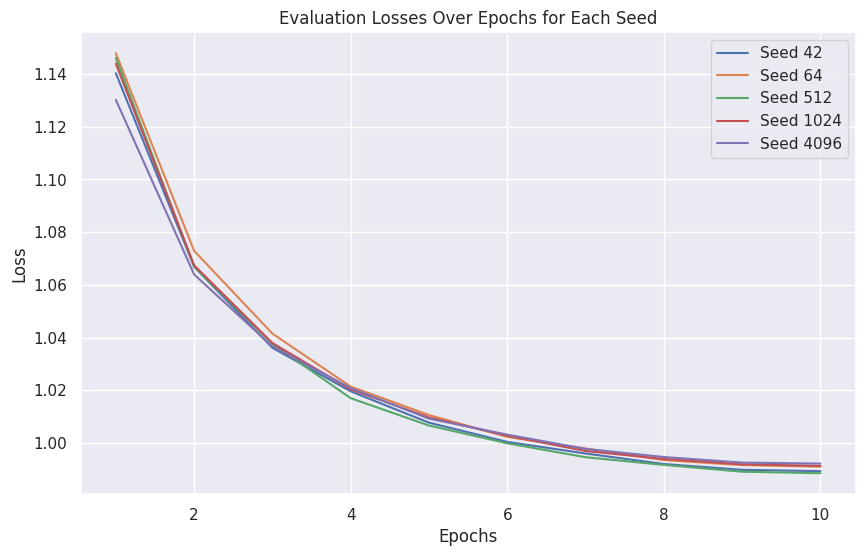

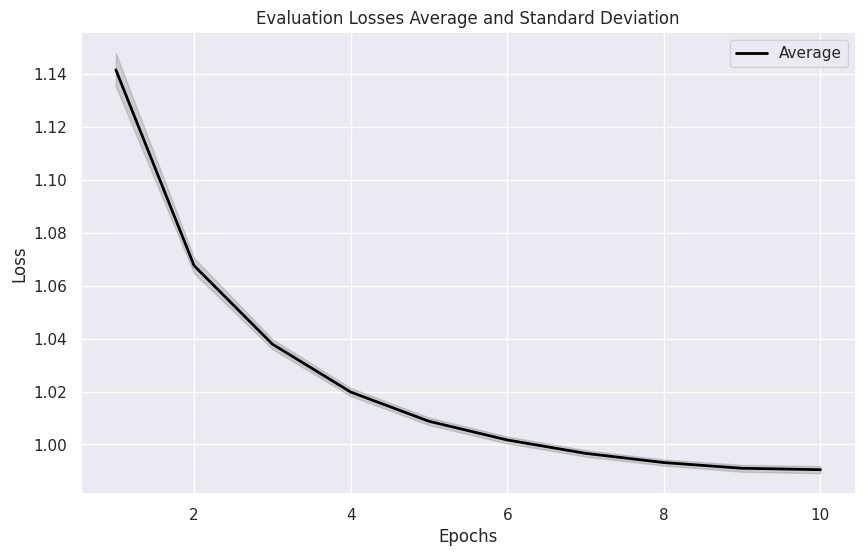

In [72]:
filename: str = "bert_freezed_encoder_history_list.json"
!wget -N https://raw.githubusercontent.com/lorenzobalzani/nlp_projects/master/project/{filename}

with open(filename, "r") as file:
      plot_evaluation_loss(json.load(file), plot_avg_std_dev=True)

### Unfreezing the encoder!

In [ ]:
seeds = [4096]
bert_unfreezed_encoder_history_list = run_training(seeds,
                                                  encoder_model_name,
                                                  bert_train_dataloader,
                                                  bert_eval_dataloader,
                                                  freeze_encoder=False)

--2024-01-10 12:26:18--  https://raw.githubusercontent.com/lorenzobalzani/nlp_projects/master/project/bert_unfreezed_encoder_history_list.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2556 (2.5K) [text/plain]
Saving to: ‘bert_unfreezed_encoder_history_list.json’

bert_unfreezed_enco 100%[===================>]   2.50K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2024-01-10 12:26:18 (54.3 MB/s) - ‘bert_unfreezed_encoder_history_list.json’ saved [2556/2556]



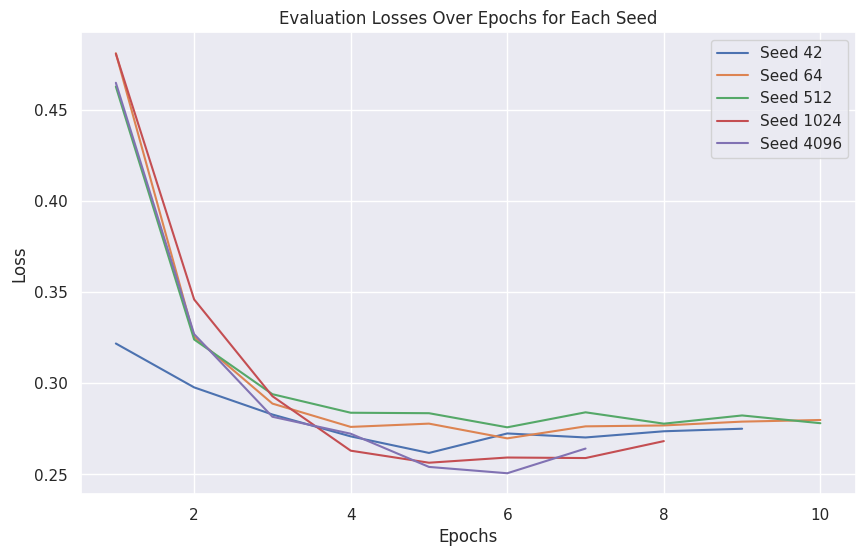

In [71]:
filename: str = "bert_unfreezed_encoder_history_list.json"
!wget -N https://raw.githubusercontent.com/lorenzobalzani/nlp_projects/master/project/{filename}

with open(filename, "r") as file:
      plot_evaluation_loss(json.load(file))

## RoBERTa-large

In [ ]:
encoder_model_name: str = "roberta-large"
roberta_large_history_list = run_training([general_random_state],
                                          encoder_model_name,
                                          roberta_large_train_dataloader,
                                          roberta_large_eval_dataloader,
                                          freeze_encoder=False)

In [ ]:
filename: str = "roberta-large_history_list.json"
!wget -N https://raw.githubusercontent.com/lorenzobalzani/nlp_projects/master/project/{filename}

with open(filename, "r") as file:
      plot_evaluation_loss(json.load(file))

# Our solution(s): Evaluation

## Model Inference

For a comprehensive understanding of the distinctions between `@torch.inference_mode()` and `torch.no_grad()`, please refer to [this page](https://pytorch.org/docs/stable/generated/torch.inference_mode.html) in the PyTorch documentation.

In [61]:
@torch.inference_mode()
def inference(model: EmotionTriggerModel,
              input: Dict[str, torch.Tensor],
              device: str,
              print_output: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
  model.eval()
  model.to(device)
  emotions, trigger_probs = model(input_ids=input["input_ids"].to(device),
                                  attention_mask=input["attention_mask"].to(device))
  if print_output:
    print("Emotions:", emotions)
    print("Ground truth emotions:", input["emotions"])
    print("Trigger Probabilities:", trigger_probs)
    print("Ground truth trigger:", input["triggers"])

  return emotions, trigger_probs

## Evaluation Scripts

In [73]:
def compute_f1_scores(y_pred: List[int], y_test: List[int]) -> Tuple[float, float]:
    if len(y_pred) != len(y_test):
        raise ValueError("Predictions and labels must be of the same length")

    # Sequence F1
    sequence_f1_scores = []
    for pred, true in zip(y_pred, y_test):
        if len(pred) != len(true):
            raise ValueError("Prediction and label dialogue lengths must match")
        sequence_f1_scores.append(f1_score(true, pred, average="macro"))

    avg_sequence_f1 = np.mean(sequence_f1_scores)

    # Unrolled Sequence F1
    all_pred = [item for sublist in y_pred for item in sublist]
    all_test = [item for sublist in y_test for item in sublist]
    unrolled_sequence_f1 = f1_score(all_test, all_pred, average="macro")

    return avg_sequence_f1, unrolled_sequence_f1

In [74]:
def print_metrics(model_name: str,
                  all_emotions_sequence_f1: float,
                  all_emotions_unrolled_f1: float,
                  all_triggers_sequence_f1: float,
                  all_triggers_unrolled_f1: float,
                  include_per_seed_metrics: bool = False) -> None:

  def calculate_avg_and_std_dev(metric_values: List[float]) -> Tuple[float, float]:
    values_array = np.array(metric_values)
    return np.mean(values_array), np.std(values_array)

  display_markdown(f"#{model_name}")

  if include_per_seed_metrics:
    display_markdown("##Seed-specific Metrics")
    for idx, seed in enumerate(seeds):
      display_markdown(f"###Seed **{seed}**")
      display_markdown(f"####Emotions")
      display_markdown(f"- Sequence F1: {all_emotions_sequence_f1[idx]:.2%}")
      display_markdown(f"- Unrolled Sequence F1: {all_emotions_unrolled_f1[idx]:.2%}")
      display_markdown(f"####Triggers")
      display_markdown(f"- Sequence F1: {all_triggers_sequence_f1[idx]:.2%}")
      display_markdown(f"- Unrolled Sequence F1: {all_triggers_unrolled_f1[idx]:.2%}")

  display_markdown("##Aggregate Metrics")
  avg, std_dev = calculate_avg_and_std_dev(all_emotions_sequence_f1)
  display_markdown(f"###Emotions")
  display_markdown(f"- Sequence F1 avg: **{avg:.2%} ± {std_dev:.2%}**")
  avg, std_dev = calculate_avg_and_std_dev(all_emotions_unrolled_f1)
  display_markdown(f"- Unrolled Sequence F1 avg: **{avg:.2%} ± {std_dev:.2%}**")

  display_markdown(f"###Triggers")
  avg, std_dev = calculate_avg_and_std_dev(all_triggers_sequence_f1)
  display_markdown(f"- Sequence F1 avg: **{avg:.2%} ± {std_dev:.2%}**")
  avg, std_dev = calculate_avg_and_std_dev(all_triggers_unrolled_f1)
  display_markdown(f"- Unrolled Sequence F1 avg: **{avg:.2%} ± {std_dev:.2%}**")

In [75]:
def evaluate_solution(encoder_model_name: str, test_dataloader: DataLoader, freeze_encoder: bool) -> None:
  all_emotions_sequence_f1 = list()
  all_emotions_unrolled_f1 = list()
  all_triggers_sequence_f1 = list()
  all_triggers_unrolled_f1 = list()
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  freezed: str = "freezed" if freeze_encoder else "unfreezed"
  model_hub_path: str = f"balzanilo/dialogs_{encoder_model_name}" + "_" + freezed + "-enc"

  with tqdm(total=len(seeds) * len(test_dataloader), position=0, leave=False, desc=f"Evaluating models with {freezed} encoder") as pbar:
    for seed in seeds:
      emotions_predictions = list()
      emotions_labels = list()
      triggers_predictions = list()
      triggers_labels = list()
      model = EmotionTriggerModel.from_pretrained(f"{model_hub_path}_seed-{seed}",
                                                encoder_model_name=encoder_model_name,
                                                num_emotions=num_emotions,
                                                num_lstm_layers=16,
                                                lstm_hidden_size=256,
                                                ffnn_hidden_size=128)
      for idx, batch in enumerate(test_dataloader):
        emotions_labels.append(batch["emotions"])
        triggers_labels.append(batch["triggers"])
        emotions, trigger_probs = inference(model, batch, device)
        emotions_probabilities = torch.softmax(emotions, dim=1)
        emotion_predictions = torch.argmax(emotions_probabilities, dim=1)
        emotions_predictions.append(emotion_predictions.cpu().numpy())
        triggers_prediction = (trigger_probs > .5).int()
        triggers_predictions.append(triggers_prediction.cpu().numpy())
        pbar.update()

      emotions_sequence_f1, emotions_unrolled_sequence_f1 = compute_f1_scores(emotions_predictions, emotions_labels)
      triggers_sequence_f1, triggers_unrolled_sequence_f1 = compute_f1_scores(triggers_predictions, triggers_labels)
      all_emotions_sequence_f1.append(emotions_sequence_f1)
      all_emotions_unrolled_f1.append(emotions_unrolled_sequence_f1)
      all_triggers_sequence_f1.append(triggers_sequence_f1)
      all_triggers_unrolled_f1.append(triggers_unrolled_sequence_f1)

  tqdm._instances.clear()

  print_metrics(f"{freezed.capitalize()} BERT",
                all_emotions_sequence_f1,
                all_emotions_unrolled_f1,
                all_triggers_sequence_f1,
                all_triggers_unrolled_f1)

### Baselines

In [76]:
def evaluate_random(test_data: pd.DataFrame) -> None:
  all_emotions_sequence_f1 = list()
  all_emotions_unrolled_f1 = list()
  all_triggers_sequence_f1 = list()
  all_triggers_unrolled_f1 = list()

  with tqdm(total=len(seeds) * len(test_data), position=0, leave=False) as pbar:
    for seed in seeds:
      model = RandomClassifier(num_emotions=num_emotions, seed=seed)
      emotions_predictions = list()
      emotions_labels = list()
      triggers_predictions = list()
      triggers_labels = list()
      for idx, batch in enumerate(test_data.iterrows()):
        emotions_labels.append(batch[1]["emotions"])
        triggers_labels.append(batch[1]["triggers"])
        emotions, triggers = model(batch[1]["utterances"])
        emotions_predictions.append(emotions)
        triggers_predictions.append(triggers)
        pbar.update()

      emotions_sequence_f1, emotions_unrolled_sequence_f1 = compute_f1_scores(emotions_predictions, emotions_labels)
      triggers_sequence_f1, triggers_unrolled_sequence_f1 = compute_f1_scores(triggers_predictions, triggers_labels)
      all_emotions_sequence_f1.append(emotions_sequence_f1)
      all_emotions_unrolled_f1.append(emotions_unrolled_sequence_f1)
      all_triggers_sequence_f1.append(triggers_sequence_f1)
      all_triggers_unrolled_f1.append(triggers_unrolled_sequence_f1)

  tqdm._instances.clear()

  print_metrics("Baseline: Random Classifier",
                all_emotions_sequence_f1,
                all_emotions_unrolled_f1,
                all_triggers_sequence_f1,
                all_triggers_unrolled_f1)

In [77]:
def evaluate_majority(train_data: pd.DataFrame) -> None:
  with tqdm(total=len(train_data), position=0, leave=False) as pbar:
    model = MajorityClassifier(train_data)
    emotions_predictions = list()
    emotions_labels = list()
    triggers_predictions = list()
    triggers_labels = list()
    for idx, batch in enumerate(train_data.iterrows()):
      emotions_labels.append(batch[1]["emotions"])
      triggers_labels.append(batch[1]["triggers"])
      emotions, triggers = model(batch[1]["utterances"])
      emotions_predictions.append(emotions)
      triggers_predictions.append(triggers)
      pbar.update()

    emotions_sequence_f1, emotions_unrolled_sequence_f1 = compute_f1_scores(emotions_predictions, emotions_labels)
    triggers_sequence_f1, triggers_unrolled_sequence_f1 = compute_f1_scores(triggers_predictions, triggers_labels)

  tqdm._instances.clear()

  display_markdown(f"#Baseline: Majority Classifier")
  display_markdown(f"##Aggregate Metrics")
  display_markdown(f"###Emotions")
  display_markdown(f"- Sequence F1: **{emotions_sequence_f1:.2%}**")
  display_markdown(f"- Unrolled Sequence F1: **{emotions_unrolled_sequence_f1:.2%}**")

  display_markdown(f"###Triggers")
  display_markdown(f"- Sequence F1 avg: **{triggers_sequence_f1:.2%}**")
  display_markdown(f"- Unrolled Sequence F1 avg: **{triggers_unrolled_sequence_f1:.2%}**")

# Conclusions: Performance Overview

In [83]:
%%time
encoder_model_name = "bert-base-uncased"
evaluate_solution(encoder_model_name, bert_test_dataloader, freeze_encoder=True)
evaluate_solution(encoder_model_name, bert_test_dataloader, freeze_encoder=False)
evaluate_random(test_data)
evaluate_majority(train_data)

#Freezed BERT

##Aggregate Metrics

###Emotions

- Sequence F1 avg: **43.00% ± 0.18%**

- Unrolled Sequence F1 avg: **33.96% ± 0.26%**

...

- Unrolled Sequence F1: **8.66%**

###Triggers

- Sequence F1 avg: **47.91%**

- Unrolled Sequence F1 avg: **45.60%**

CPU times: user 2min 12s, sys: 5.47 s, total: 2min 18s
Wall time: 2min 39s
